# GOES ABI CONUS - True Color

The CONUS sector in True Color: the whole sector, then a box inside it. CONUS refreshes every 5 minutes against 10 for the Full Disk, but on this date it stops short of Alaska.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/),
then point `DATA_DIR` at the folder they landed in. Nothing is downloaded here.

**Steps:** your files -> the whole scan -> your box -> that box.

The plotting is plain matplotlib and cartopy, written out where it happens, so
change the colours, the projection or anything else right there.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml

sys.path.insert(0, "..")
import goestools as gt

CONFIG = yaml.safe_load(open("../config.yml"))
STYLE = CONFIG["style"]          # colours, widths, figure size


## 1. Your files

In [2]:
DATA_DIR = Path("..") / CONFIG["data"]["conus"]
CHANNELS = ["C01", "C02", "C03"]                # all from the SAME scan

files = sorted(glob.glob(str(DATA_DIR / "*.nc")))
print(f"{DATA_DIR}: {len(files)} file(s)")
for name in files:
    print("   ", Path(name).name)

paths = gt.find_channels(files, CHANNELS)    # raises if one is missing


../data/conus: 4 file(s)
    OR_ABI-L1b-RadC-M6C01_G18_s20232761901171_e20232761903544_c20232761903586.nc
    OR_ABI-L1b-RadC-M6C02_G18_s20232761901171_e20232761903545_c20232761903565.nc
    OR_ABI-L1b-RadC-M6C03_G18_s20232761901171_e20232761903544_c20232761903579.nc
    OR_ABI-L1b-RadC-M6C13_G18_s20232761901171_e20232761903556_c20232761904010.nc


## 2. The whole scan

Drawn in the satellite's own Geostationary projection. Channels at 0.5, 1 and
2 km are lined up by averaging the finer one down by an exact integer factor,
so nothing is interpolated.

<Composite True Color (375, 625, 3) at 2023-10-03 19:01:17.197269>


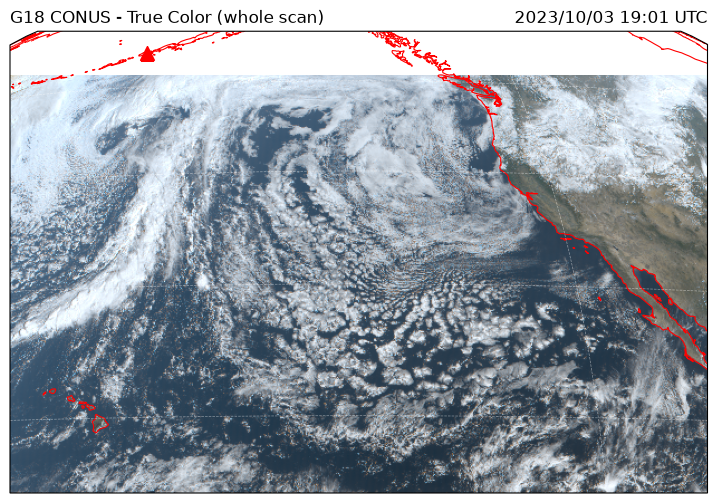

In [3]:
whole = gt.true_color(files, stride=STYLE["overview_stride"])
print(whole)

crs = gt.cartopy_crs(whole.gs)
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(1, 1, 1, projection=crs)

ax.imshow(np.clip(np.nan_to_num(whole.rgb), 0, 1), origin="upper",
          extent=whole.extent, transform=crs)

ax.coastlines(resolution="50m", color=STYLE["coast_colour"],
              linewidth=STYLE["coast_width"])
ax.gridlines(color=STYLE["grid_colour"], alpha=STYLE["grid_alpha"],
             linestyle=STYLE["grid_style"], linewidth=STYLE["grid_width"])
if STYLE["marker_lon"] is not None:
    ax.plot(STYLE["marker_lon"], STYLE["marker_lat"], "^",
            color=STYLE["marker_colour"], ms=STYLE["marker_size"],
            transform=ccrs.PlateCarree())

ax.set_title("G18 CONUS - " + whole.name + " (whole scan)", loc="left")
ax.set_title(f"{whole.time:%Y/%m/%d %H:%M} UTC", loc="right")
plt.show()


## 3. Your box

In [4]:
# YOUR BOX -- four numbers, decimal degrees. There is no preset.
#     LON_MIN, LON_MAX, LAT_MIN, LAT_MAX      (west, east, south, north)
# Set BOX = None to skip the crop.
BOX = (-124.0, -114.0, 33.0, 42.0)

print("box:", BOX)


box: (-124.0, -114.0, 33.0, 42.0)


## 4. Your box

<Composite True Color (731, 999, 3) at 2023-10-03 19:01:17.197269>


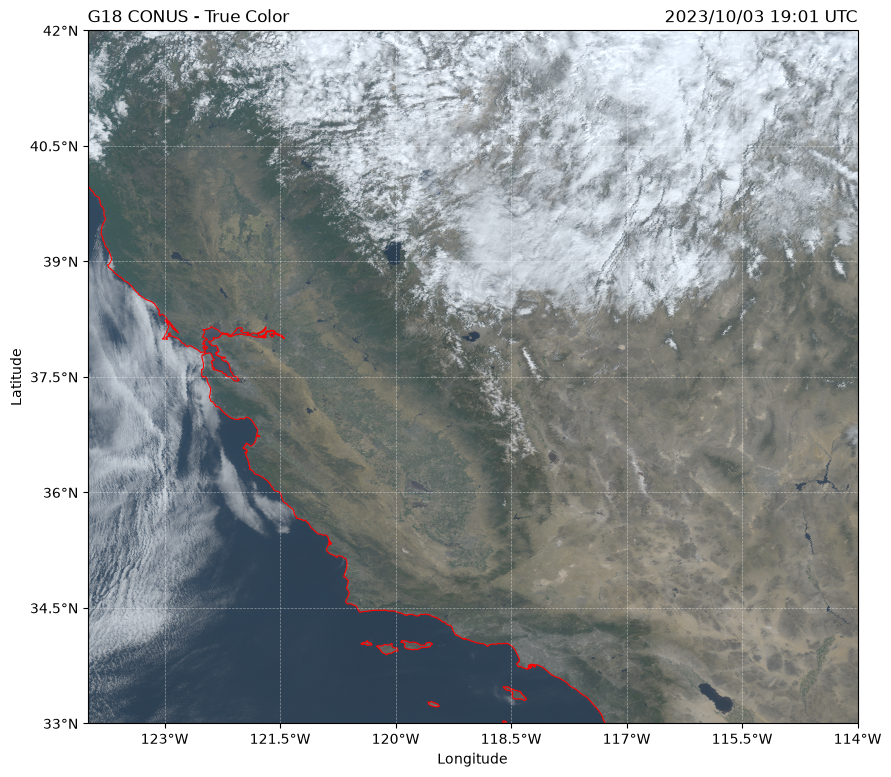

In [5]:
if BOX is None:
    print("No box set.")
else:
    rgb = gt.true_color(files, *BOX)
    print(rgb)

    fig = plt.figure(figsize=(STYLE["figure_width"], 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    gt.draw_rgb(ax, rgb, transform=ccrs.PlateCarree())

    ax.coastlines(resolution=STYLE["coast_resolution"],
                  color=STYLE["coast_colour"], linewidth=STYLE["coast_width"])
    ax.gridlines(color=STYLE["grid_colour"], alpha=STYLE["grid_alpha"],
                 linestyle=STYLE["grid_style"], linewidth=STYLE["grid_width"])
    gt.degree_ticks(ax, *BOX)
    if STYLE["marker_lon"] is not None:
        ax.plot(STYLE["marker_lon"], STYLE["marker_lat"], "^",
                color=STYLE["marker_colour"], ms=STYLE["marker_size"],
                transform=ccrs.PlateCarree())

    ax.set_extent(BOX, crs=ccrs.PlateCarree())
    ax.set_title("G18 CONUS - " + rgb.name, loc="left")
    ax.set_title(f"{rgb.time:%Y/%m/%d %H:%M} UTC", loc="right")
    plt.show()


## Reading the colours

Ocean dark blue, land green to brown, cloud and snow white.

See [docs/RGB.md](../docs/RGB.md).